# Estudo de Caso - Previsão de Attrition (Rotatividade de Funcionários)

---
## **Contexto**
---

A McCurr Health Consultancy é uma empresa global com muitos funcionários. A empresa gasta muito dinheiro tentando reter bons trabalhadores. Para economizar, o Head of People Operations quer oferecer incentivos apenas para funcionários com risco de sair (attrition risk). Como Cientista de Dados, seu trabalho é estudar dados passados, identificar padrões de quem saiu e prever quais funcionários atuais estão em risco de sair para que a empresa possa apoiá-los.

---
## **Objetivo**
---

* Identificar os diferentes fatores que levam à rotatividade
* Construir um modelo para prever se um funcionário vai sair ou não

---
## **Descrição do Dataset**
---

Os dados contêm informações sobre detalhes demográficos dos funcionários, métricas relacionadas ao trabalho e a flag de rotatividade.

* **EmployeeNumber** - Identificador único do funcionário
* **Attrition** - O funcionário saiu ou não?
* **Age** - Idade do funcionário
* **BusinessTravel** - Compromissos de viagem para o trabalho
* **DailyRate** - Descrição dos dados não disponível
* **Department** - Departamento do funcionário
* **DistanceFromHome** - Distância do trabalho até a casa (em KM)
* **Education** - Educação do funcionário. 1-Abaixo do Ensino Médio, 2-Ensino Médio, 3-Graduação, 4-Mestrado, 5-Doutorado
* **EducationField** - Área de formação
* **EnvironmentSatisfaction** - 1-Baixa, 2-Média, 3-Alta, 4-Muito Alta
* **Gender** - Gênero do funcionário
* **HourlyRate** - Descrição dos dados não disponível
* **JobInvolvement** - 1-Baixo, 2-Médio, 3-Alto, 4-Muito Alto
* **JobLevel** - Nível do cargo (1 a 5)
* **JobRole** - Função do cargo
* **JobSatisfaction** - 1-Baixa, 2-Média, 3-Alta, 4-Muito Alta
* **MaritalStatus** - Estado civil
* **MonthlyIncome** - Salário mensal
* **MonthlyRate** - Descrição dos dados não disponível
* **NumCompaniesWorked** - Número de empresas em que trabalhou
* **Over18** - O funcionário tem mais de 18 anos?
* **OverTime** - O funcionário faz horas extras?
* **PercentSalaryHike** - Percentual de aumento salarial no último ano
* **PerformanceRating** - 1-Baixa, 2-Boa, 3-Excelente, 4-Excepcional
* **RelationshipSatisfaction** - 1-Baixa, 2-Média, 3-Alta, 4-Muito Alta
* **StandardHours** - Horas padrão
* **StockOptionLevel** - Nível de opções de ações
* **TotalWorkingYears** - Total de anos trabalhados
* **TrainingTimesLastYear** - Número de treinamentos frequentados no último ano
* **WorkLifeBalance** - 1-Baixo, 2-Bom, 3-Excelente, 4-Excepcional
* **YearsAtCompany** - Anos na empresa
* **YearsInCurrentRole** - Anos no cargo atual
* **YearsSinceLastPromotion** - Anos desde a última promoção
* **YearsWithCurrManager** - Anos com o gerente atual

**No mundo real, você não encontrará definições para algumas de suas variáveis. Faz parte da análise descobrir o que elas podem significar**.

---
## **Pipeline de Machine Learning**
---

Este notebook segue as fases clássicas de um pipeline de Machine Learning:

* **Fase 0: Preparação dos Dados** - Conversão do Excel para Parquet
* **Fase 1: Data Cleaning** - Limpeza e preparação inicial dos dados
* **Fase 2: Feature Engineering** - Criação de features e transformações
* **Fase 3: Train/Test Split** - Divisão dos dados em treino e teste
* **Fase 4: Modelagem** - Treinamento, avaliação e interpretação dos modelos


## Configuração Inicial e Importações

In [1]:
# Instalar bibliotecas necessárias (caso não estejam instaladas)
!pip install pandas openpyxl xlrd pyarrow -q

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, sum as spark_sum, countDistinct
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Configurar visualização
sns.set(style="whitegrid")

## Definição dos Caminhos dos Arquivos

Definimos os caminhos para o arquivo Excel original, o Parquet intermediário e os resultados.

In [2]:
EXCEL_PATH = "/content/drive/MyDrive/pucsp-deeplearning/I2.2-Employee_Attrition_DataSet.xlsx"
PARQUET_PATH = "/content/drive/MyDrive/pucsp-deeplearning/I2.2-employee_attrition.parquet"
PROCESSED_PARQUET_PATH = "/content/drive/MyDrive/pucsp-deeplearning/I2.2-employee_attrition_processed.parquet"
PREDICTIONS_PARQUET_PATH = "/content/drive/MyDrive/pucsp-deeplearning/I2.2-predictions.parquet"

## Inicialização dos Dataset

In [3]:
# Montar Google Drive (para Colab)
from google.colab import drive
drive.mount('/content/drive')

# Inicializar Spark Session
spark = SparkSession.builder \
    .appName("EmployeeAttritionPrediction") \
    .config("spark.sql.adaptive.enabled", "false") \
    .getOrCreate()

Mounted at /content/drive


# FASE 0: PREPARAÇÃO DOS DADOS - CONVERSÃO EXCEL → PARQUET

Carregamos o arquivo Excel original usando pandas e salvamos como Parquet para uso no PySpark.

In [4]:
print("\n" + "="*60)
print("FASE 0: PREPARAÇÃO DOS DADOS")
print("="*60)


FASE 0: PREPARAÇÃO DOS DADOS


In [5]:
# Ler o arquivo Excel com pandas
pdf = pd.read_excel(EXCEL_PATH)
print(f"Arquivo Excel carregado: {pdf.shape[0]} linhas, {pdf.shape[1]} colunas")

# Salvar como Parquet (usando pyarrow)
pdf.to_parquet(PARQUET_PATH, index=False)
print(f"Arquivo Parquet salvo em: {PARQUET_PATH}")

Arquivo Excel carregado: 2940 linhas, 34 colunas
Arquivo Parquet salvo em: /content/drive/MyDrive/pucsp-deeplearning/I2.2-employee_attrition.parquet


In [6]:
# Verificar se o arquivo foi criado
import os
if os.path.exists(PARQUET_PATH):
    print("Arquivo Parquet criado com sucesso.")
else:
    print("Falha ao criar o arquivo Parquet.")

Arquivo Parquet criado com sucesso.


## Verificação inicial do Dataset

In [7]:
# Carregar dados do Parquet
df = spark.read.parquet(PARQUET_PATH)
print(f"Registros carregados: {df.count()}")

Registros carregados: 2940


In [8]:
# Visualizar as primeiras linhas (equivalente ao df.head() do pandas)
print("\nPrimeiras 5 linhas:")
df.show(5, truncate=False)


Primeiras 5 linhas:
+--------------+---------+---+-----------------+---------+----------------------+----------------+---------+--------------+-----------------------+------+----------+--------------+--------+---------------------+---------------+-------------+-------------+-----------+------------------+------+--------+-----------------+-----------------+------------------------+-------------+----------------+-----------------+---------------------+---------------+--------------+------------------+-----------------------+--------------------+
|EmployeeNumber|Attrition|Age|BusinessTravel   |DailyRate|Department            |DistanceFromHome|Education|EducationField|EnvironmentSatisfaction|Gender|HourlyRate|JobInvolvement|JobLevel|JobRole              |JobSatisfaction|MaritalStatus|MonthlyIncome|MonthlyRate|NumCompaniesWorked|Over18|OverTime|PercentSalaryHike|PerformanceRating|RelationshipSatisfaction|StandardHours|StockOptionLevel|TotalWorkingYears|TrainingTimesLastYear|WorkLifeBalance

In [9]:
# Informações do DataFrame (equivalente ao df.info() do pandas)
print("\nEsquema do DataFrame:")
df.printSchema()


Esquema do DataFrame:
root
 |-- EmployeeNumber: long (nullable = true)
 |-- Attrition: string (nullable = true)
 |-- Age: long (nullable = true)
 |-- BusinessTravel: string (nullable = true)
 |-- DailyRate: long (nullable = true)
 |-- Department: string (nullable = true)
 |-- DistanceFromHome: long (nullable = true)
 |-- Education: long (nullable = true)
 |-- EducationField: string (nullable = true)
 |-- EnvironmentSatisfaction: long (nullable = true)
 |-- Gender: string (nullable = true)
 |-- HourlyRate: long (nullable = true)
 |-- JobInvolvement: long (nullable = true)
 |-- JobLevel: long (nullable = true)
 |-- JobRole: string (nullable = true)
 |-- JobSatisfaction: long (nullable = true)
 |-- MaritalStatus: string (nullable = true)
 |-- MonthlyIncome: long (nullable = true)
 |-- MonthlyRate: long (nullable = true)
 |-- NumCompaniesWorked: long (nullable = true)
 |-- Over18: string (nullable = true)
 |-- OverTime: string (nullable = true)
 |-- PercentSalaryHike: long (nullable = tru

In [10]:
# Número de valores únicos por coluna (equivalente ao df.nunique() do pandas)
from pyspark.sql.functions import countDistinct
print("\nNúmero de valores únicos por coluna:")
nunique_expr = [countDistinct(col(c)).alias(c) for c in df.columns]
nunique_df = df.select(nunique_expr).toPandas().T
nunique_df.columns = ['Unique_Count']
print(nunique_df)


Número de valores únicos por coluna:
                          Unique_Count
EmployeeNumber                    2940
Attrition                            2
Age                                 43
BusinessTravel                       3
DailyRate                          886
Department                           3
DistanceFromHome                    29
Education                            5
EducationField                       6
EnvironmentSatisfaction              4
Gender                               2
HourlyRate                          71
JobInvolvement                       4
JobLevel                             5
JobRole                              9
JobSatisfaction                      4
MaritalStatus                        3
MonthlyIncome                     1349
MonthlyRate                       1427
NumCompaniesWorked                  10
Over18                               1
OverTime                             2
PercentSalaryHike                   15
PerformanceRating         

**Observações:**

- **EmployeeNumber** é um identificador único para cada funcionário e podemos descartar esta coluna, pois não agregaria valor à nossa análise.
- **Over18** e **StandardHours** possuem apenas 1 valor único. Essas colunas não agregarão valor ao nosso modelo, portanto podemos descartá-las.
- Com base no número de valores únicos em cada coluna e na descrição dos dados, podemos identificar as colunas contínuas e categóricas nos dados.

In [11]:
print("\n--- FASE 0 CONCLUÍDA ---")


--- FASE 0 CONCLUÍDA ---


# FASE 1: DATA CLEANING

Nesta fase, removemos colunas desnecessárias, verificamos valores nulos e codificamos a variável alvo.

In [12]:
print("\n" + "="*60)
print("FASE 1: DATA CLEANING")
print("="*60)


FASE 1: DATA CLEANING


In [13]:
# Remover colunas desnecessárias (identificadores e colunas com valor único)
cols_to_drop = ["EmployeeNumber", "Over18", "StandardHours"]
df = df.drop(*cols_to_drop)
print(f"\nColunas removidas: {cols_to_drop}")


Colunas removidas: ['EmployeeNumber', 'Over18', 'StandardHours']


In [14]:
# Verificar valores nulos (não há, mas por segurança)
null_counts = df.select([spark_sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).toPandas().T
null_counts.columns = ['Null_Count']
print("\nContagem de nulos por coluna:")
print(null_counts)


Contagem de nulos por coluna:
                          Null_Count
Attrition                          0
Age                                0
BusinessTravel                     0
DailyRate                          0
Department                         0
DistanceFromHome                   0
Education                          0
EducationField                     0
EnvironmentSatisfaction            0
Gender                             0
HourlyRate                         0
JobInvolvement                     0
JobLevel                           0
JobRole                            0
JobSatisfaction                    0
MaritalStatus                      0
MonthlyIncome                      0
MonthlyRate                        0
NumCompaniesWorked                 0
OverTime                           0
PercentSalaryHike                  0
PerformanceRating                  0
RelationshipSatisfaction           0
StockOptionLevel                   0
TotalWorkingYears                  0
Trainin

In [15]:
# Codificar a variável alvo "Attrition" (Yes -> 1, No -> 0)
df = df.withColumn("Attrition", when(col("Attrition") == "Yes", 1).otherwise(0))
print("\nVariável alvo codificada: Attrition (1=Sim, 0=Não)")


Variável alvo codificada: Attrition (1=Sim, 0=Não)


In [16]:
print(f"Dados após limpeza: {df.count()} registros, {len(df.columns)} colunas.")

Dados após limpeza: 2940 registros, 31 colunas.


In [17]:
print("\n--- FASE 1 CONCLUÍDA ---")


--- FASE 1 CONCLUÍDA ---


# FASE 2: FEATURE ENGINEERING

Aqui criamos as features adequadas para modelagem. Identificamos colunas categóricas e numéricas e aplicamos transformações (StringIndexer + OneHotEncoder para categóricas) e montamos um vetor de features com VectorAssembler.

In [18]:
print("\n" + "="*60)
print("FASE 2: FEATURE ENGINEERING")
print("="*60)


FASE 2: FEATURE ENGINEERING


In [19]:
# Identificar colunas categóricas e numéricas de forma dinâmica
# Alterado a checagem numérica para incluir 'long', 'bigint', 'short', etc.
categorical_cols = [c for c, t in df.dtypes if t == "string" and c != "Attrition"]
numeric_cols = [c for c, t in df.dtypes if any(x in t for x in ("int", "double", "float", "long", "bigint")) and c != "Attrition"]

print(f"Colunas categóricas: {categorical_cols}")
print(f"Colunas numéricas: {numeric_cols}")

Colunas categóricas: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Colunas numéricas: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


Um Pipeline é uma sequência organizada de etapas de pré-processamento que transforma os dados brutos em um formato adequado para treinamento e predição.

In [20]:
# Criar pipeline de transformação
stages = []

# Transforma "Yes"/"No" em 1.0/0.0 e cria a coluna padrão "label"
target_indexer = StringIndexer(inputCol="Attrition", outputCol="label", handleInvalid="keep")
stages.append(target_indexer)

# Processar as colunas categóricas preditoras
for col_name in categorical_cols:
    indexer = StringIndexer(inputCol=col_name, outputCol=col_name + "_index", handleInvalid="keep")
    encoder = OneHotEncoder(inputCol=col_name + "_index", outputCol=col_name + "_vec")
    stages += [indexer, encoder]

# Mapear as entradas do assembler (numéricas + vetores categóricos)
assembler_input_cols = numeric_cols + [c + "_vec" for c in categorical_cols]

assembler = VectorAssembler(inputCols=assembler_input_cols, outputCol="features")
stages += [assembler]

In [21]:
# Criar e aplicar o Pipeline
pipeline = Pipeline(stages=stages)
model_pipeline = pipeline.fit(df)
df_transformed = model_pipeline.transform(df)

print("\nPipeline de transformação criado e aplicado.")
print(f"Dados transformados: {df_transformed.count()} registros, {len(df_transformed.columns)} colunas.")

print("\nAmostra dos dados transformados (features e target):")
# Agora selecionamos "label" (numérica) em vez de "Attrition" (string)
df_transformed.select("label", "features").show(5, truncate=False)


Pipeline de transformação criado e aplicado.
Dados transformados: 2940 registros, 47 colunas.

Amostra dos dados transformados (features e target):
+-----+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|label|features                                                                                                                                                                                                                      |
+-----+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|1.0  |(51,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,16,18,19,20,22,23,27,29,36,37,47,50],[41.0,1102.0,1.0,2.0,2.0,94.0,3.0,2.0,4.0,5993.0,19479.0,8.0,11.0,3.0,1.0,

> **Observação:** O DataFrame `df_transformed` é utilizado apenas para visualizar como o **Pipeline** transforma os dados originais em um vetor de características (*features*). O treinamento e a avaliação dos modelos serão realizados utilizando um **Pipeline ajustado apenas com os dados de treinamento**, evitando **data leakage** (vazamento de informação entre os conjuntos de treinamento e teste).

In [22]:
print("\n--- FASE 2 CONCLUÍDA ---")


--- FASE 2 CONCLUÍDA ---


# FASE 3: TRAIN/TEST SPLIT

Separamos os dados em conjunto de treino (70%) e teste (30%) para avaliar o desempenho dos modelos.

In [23]:
print("\n" + "="*60)
print("FASE 3: TRAIN/TEST SPLIT")
print("="*60)


FASE 3: TRAIN/TEST SPLIT


In [24]:
train_df, test_df = df.randomSplit([0.7, 0.3], seed=42)
train_df.cache()
test_df.cache()

print(f"Tamanho do treino: {train_df.count()} registros")
print(f"Tamanho do teste: {test_df.count()} registros")

Tamanho do treino: 2114 registros
Tamanho do teste: 826 registros


In [25]:
train_attrition = train_df.groupBy("Attrition").count().toPandas()
test_attrition = test_df.groupBy("Attrition").count().toPandas()

print("\nDistribuição da variável alvo no treino:")
print(train_attrition)
print("\nDistribuição da variável alvo no teste:")
print(test_attrition)


Distribuição da variável alvo no treino:
   Attrition  count
0          1    331
1          0   1783

Distribuição da variável alvo no teste:
   Attrition  count
0          1    143
1          0    683


In [26]:
print("\n--- FASE 3 CONCLUÍDA ---")


--- FASE 3 CONCLUÍDA ---


# FASE 4: MODELAGEM

Treinamos dois modelos de classificação: Árvore de Decisão e Random Forest. Avaliamos com acurácia, matriz de confusão e importância das features.

In [27]:
print("\n" + "="*60)
print("FASE 4: MODELAGEM")
print("="*60)


FASE 4: MODELAGEM


## Função Auxiliar para Avaliação de Modelos

In [28]:
# Helper function to display results no PySpark
def show_results(predictions, model_name):
    # O Spark trabalha com dados distribuídos, então extraímos as colunas
    # de rótulo (label) e predição (prediction) para o formato Pandas local.
    # Certifique-se de que no seu modelo Spark as colunas se chamam 'label' e 'prediction'.
    y_test = predictions.select("Attrition").toPandas()
    y_pred = predictions.select("prediction").toPandas()

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"--- {model_name} Results ---")
    print(f"Accuracy: {acc:.2%}")
    print("\nClassification Report:\n")

    # Updated to include target_names for clarity in the report
    print(classification_report(y_test, y_pred, target_names=['Not Attrite', 'Attrite']))

    # --- METRIC EXPLANATIONS ---[cite: 1]
    print("\nMetric Explanation:")
    print("Precision  = TP / (TP + FP)")
    print("  → Of the employees predicted as 'Attrite' (likely to leave), how many actually left?")

    print("\nRecall     = TP / (TP + FN)")
    print("  → Of the employees who actually left, how many did we correctly predict?")

    print("\nF1-Score   = 2 * (Precision * Recall) / (Precision + Recall)")
    print("  → Harmonic mean of Precision and Recall (balances both).")

    print("\nSupport    = Number of actual samples in each class")
    print("  → How many real employees are in 'Not Attrite' and 'Attrite' in our test data.")
    print("-" * 50)
    # --------------------------------------------

    # Confusion Matrix[cite: 1]
    plt.figure(figsize=(8,5))
    cm = confusion_matrix(y_test, y_pred)
    # O fmt='.2f' foi mantido conforme o original, mas para matrizes de contagem inteira 'd' ou 'g' muitas vezes evitam erros visuais[cite: 1].
    sns.heatmap(cm, annot=True,  fmt='g', xticklabels=['Not Attrite', 'Attrite'], yticklabels=['Not Attrite', 'Attrite'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.title(f'Right/Wrong Table (Confusion Matrix) - {model_name}')
    plt.show()

In [29]:
# Ajustamos o pipeline aos dados de treino (para aprender indexações, se houver)
pipeline_model = pipeline.fit(train_df)

# Transformamos os DataFrames de treino e teste para criarem a coluna "features"
train_df_transformed = pipeline_model.transform(train_df)
test_df_transformed = pipeline_model.transform(test_df)

## 3.1. Árvore de Decisão

In [30]:
print("\n--- Árvore de Decisão ---")
# Inicializar e treinar Decision Tree
dt = DecisionTreeClassifier(labelCol="Attrition", featuresCol="features", seed=42)
dt_model = dt.fit(train_df_transformed)


--- Árvore de Decisão ---


--- Árvore de Decisão Results ---
Accuracy: 85.96%

Classification Report:

              precision    recall  f1-score   support

 Not Attrite       0.88      0.95      0.92       683
     Attrite       0.65      0.41      0.50       143

    accuracy                           0.86       826
   macro avg       0.77      0.68      0.71       826
weighted avg       0.84      0.86      0.85       826


Metric Explanation:
Precision  = TP / (TP + FP)
  → Of the employees predicted as 'Attrite' (likely to leave), how many actually left?

Recall     = TP / (TP + FN)
  → Of the employees who actually left, how many did we correctly predict?

F1-Score   = 2 * (Precision * Recall) / (Precision + Recall)
  → Harmonic mean of Precision and Recall (balances both).

Support    = Number of actual samples in each class
  → How many real employees are in 'Not Attrite' and 'Attrite' in our test data.
--------------------------------------------------


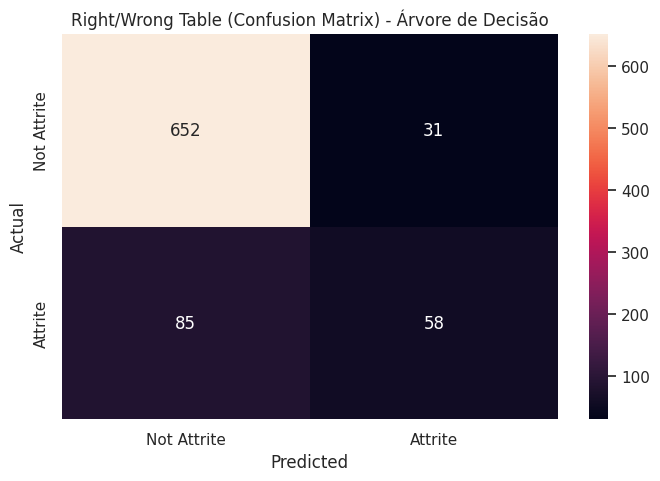

In [31]:
# Avaliar Decision Tree
dt_predictions = dt_model.transform(test_df_transformed)
show_results(dt_predictions, "Árvore de Decisão")


--- Importância das Features (Árvore de Decisão) ---
                    Feature  Importance
9             MonthlyIncome    0.157410
16        TotalWorkingYears    0.068345
11       NumCompaniesWorked    0.068000
8           JobSatisfaction    0.067794
1                 DailyRate    0.062249
5                HourlyRate    0.059479
4   EnvironmentSatisfaction    0.049459
20       YearsInCurrentRole    0.026102
0                       Age    0.021137
7                  JobLevel    0.017058


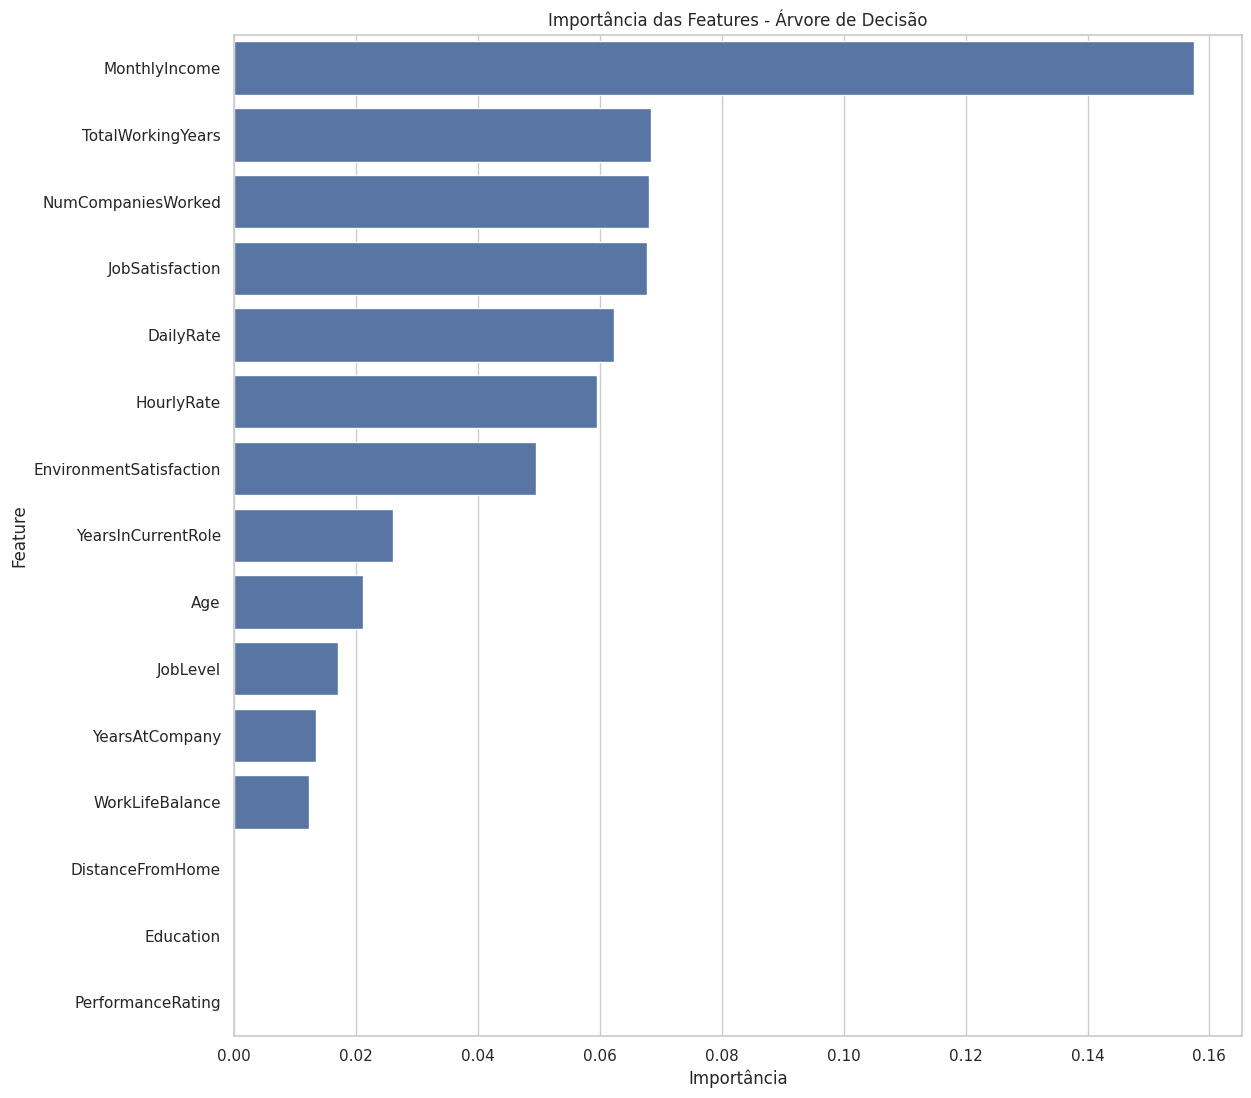

In [32]:
# Importância das features
dt_importances = dt_model.featureImportances
feature_names = assembler_input_cols
dt_importance_list = [(name, imp) for name, imp in zip(feature_names, dt_importances)]
dt_importance_df = pd.DataFrame(dt_importance_list, columns=["Feature", "Importance"]).sort_values(by="Importance", ascending=False)

print("\n--- Importância das Features (Árvore de Decisão) ---")
print(dt_importance_df.head(10))

plt.figure(figsize=(13, 13))
sns.barplot(data=dt_importance_df.head(15), x="Importance", y="Feature")
plt.title("Importância das Features - Árvore de Decisão")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.show()

**Observações:**

* De acordo com a **Árvore de Decisão**, a **Renda Mensal (Monthly Income)** é a característica mais importante, seguida por **Total de Anos de Experiência (Total Working Years)**, **Número de Empresas em que Trabalhou (Number of Companies Worked)**, **Satisfação no Trabalho (Job Satisfaction)** e **Salário Diário (Daily Rate)**.
* Outras características importantes são **Valor da Hora (Hourly Rate)**, **Satisfação com o Ambiente de Trabalho (Environment Satisfaction)**, **Anos no Cargo Atual (Years in Current Role)**, **Idade (Age)** e **Nível do Cargo (Job Level)**.

**A Árvore de Decisão utiliza UMA única árvore de perguntas para fazer previsões, enquanto a Floresta Aleatória (Random Forest) utiliza MUITAS árvores de decisão diferentes e faz uma votação para decidir a resposta final.** 🌳 vs 🌲🌲🌲


## 4.2. Random Forest

**Diferença**: Decision Tree usa UMA árvore de perguntas, enquanto Random Forest usa MUITAS árvores diferentes e faz uma votação para decidir a resposta final. 🌳 vs 🌲🌲🌲

In [33]:
print("\n--- Random Forest ---")
# Inicializar e treinar Random Forest
rf = RandomForestClassifier(
    labelCol="Attrition",
    featuresCol="features",
    seed=42,
    numTrees=500,
    maxDepth=8,
    maxBins=128
)
rf_model = rf.fit(train_df_transformed)


--- Random Forest ---


--- Random Forest Results ---
Accuracy: 88.98%

Classification Report:

              precision    recall  f1-score   support

 Not Attrite       0.89      0.99      0.94       683
     Attrite       0.93      0.39      0.55       143

    accuracy                           0.89       826
   macro avg       0.91      0.69      0.74       826
weighted avg       0.89      0.89      0.87       826


Metric Explanation:
Precision  = TP / (TP + FP)
  → Of the employees predicted as 'Attrite' (likely to leave), how many actually left?

Recall     = TP / (TP + FN)
  → Of the employees who actually left, how many did we correctly predict?

F1-Score   = 2 * (Precision * Recall) / (Precision + Recall)
  → Harmonic mean of Precision and Recall (balances both).

Support    = Number of actual samples in each class
  → How many real employees are in 'Not Attrite' and 'Attrite' in our test data.
--------------------------------------------------


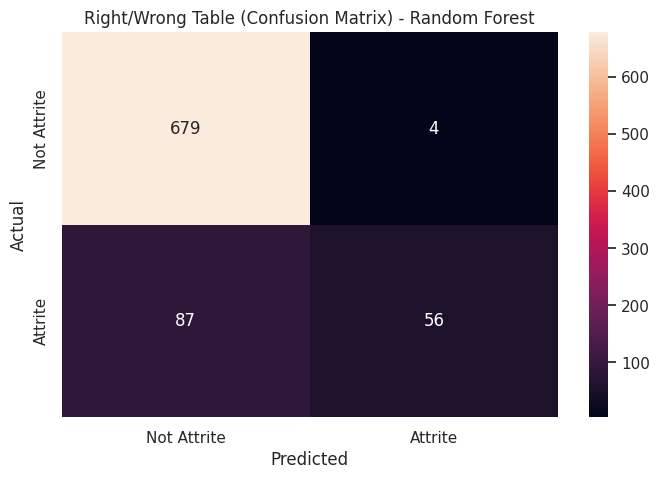

In [34]:
# Avaliar Random Forest
rf_predictions = rf_model.transform(test_df_transformed)
show_results(rf_predictions, "Random Forest")


--- Importância das Features (Random Forest) ---
                    Feature  Importance
9             MonthlyIncome    0.077993
0                       Age    0.064049
16        TotalWorkingYears    0.056633
1                 DailyRate    0.050050
19           YearsAtCompany    0.043178
2          DistanceFromHome    0.038760
5                HourlyRate    0.038009
10              MonthlyRate    0.034779
4   EnvironmentSatisfaction    0.034142
11       NumCompaniesWorked    0.031875


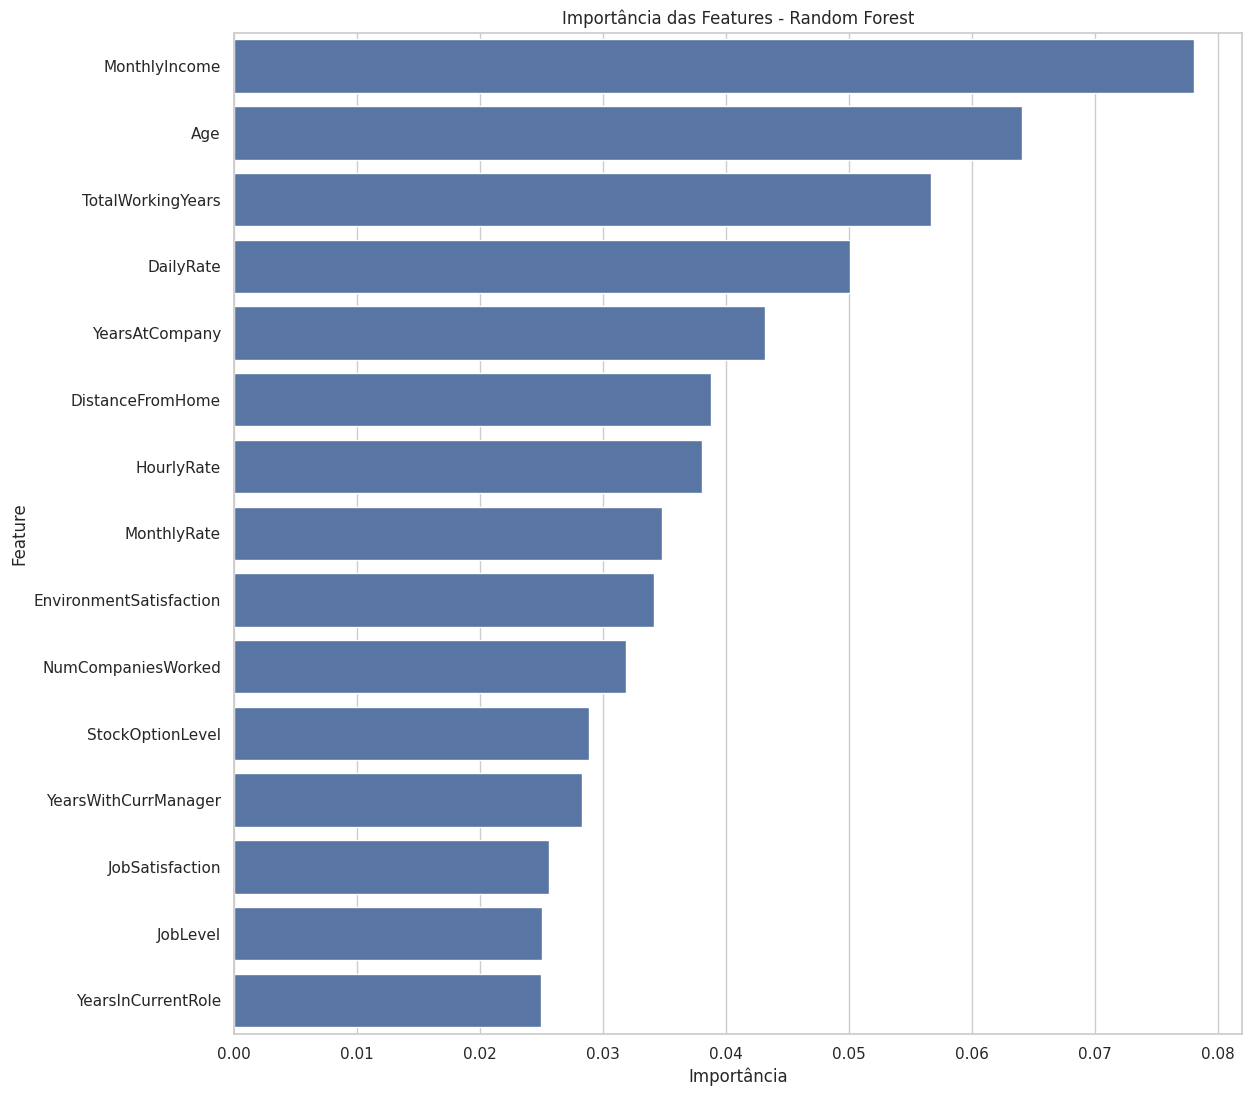

In [35]:
# Importância das features
rf_importances = rf_model.featureImportances
rf_importance_list = [(name, imp) for name, imp in zip(feature_names, rf_importances)]
rf_importance_df = pd.DataFrame(rf_importance_list, columns=["Feature", "Importance"]).sort_values(by="Importance", ascending=False)

print("\n--- Importância das Features (Random Forest) ---")
print(rf_importance_df.head(10))

plt.figure(figsize=(13, 13))
sns.barplot(data=rf_importance_df.head(15), x="Importance", y="Feature")
plt.title("Importância das Features - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.show()

**Observações:**

* De acordo com a **Random Forest**, a **Renda Mensal (Monthly Income)** é a característica mais importante, seguida por **Idade (Age)**, **Total de Anos de Experiência (Total Working Years)**, **Salário Diário (Daily Rate)** e **Tempo de Empresa (Years at Company)**.
* Outras características importantes são **Distância de Casa (Distance From Home)**, **Valor da Hora (Hourly Rate)**, **Salário Mensal (Monthly Rate)**, **Satisfação com o Ambiente de Trabalho (Environment Satisfaction)** e **Número de Empresas em que Trabalhou (Number of Companies Worked)**.

In [36]:
print("\n--- FASE 4 CONCLUÍDA ---")


--- FASE 4 CONCLUÍDA ---


## Salvando Resultados

Salvamos as previsões do Random Forest e os dados transformados em formato Parquet para uso futuro.

In [37]:
print("\n" + "="*60)
print("SALVANDO RESULTADOS")
print("="*60)

rf_predictions.select("Attrition", "prediction", "probability").write.mode("overwrite").parquet(PREDICTIONS_PARQUET_PATH)
df_transformed.select("Attrition", "features").write.mode("overwrite").parquet(PROCESSED_PARQUET_PATH)

print(f"Predições salvas em: {PREDICTIONS_PARQUET_PATH}")
print(f"Dados processados salvos em: {PROCESSED_PARQUET_PATH}")


SALVANDO RESULTADOS
Predições salvas em: /content/drive/MyDrive/pucsp-deeplearning/I2.2-predictions.parquet
Dados processados salvos em: /content/drive/MyDrive/pucsp-deeplearning/I2.2-employee_attrition_processed.parquet


## Recomendações Finais

Neste estudo foram comparados dois algoritmos de aprendizado de máquina para prever a rotatividade de funcionários (**Employee Attrition**): **Árvore de Decisão (Decision Tree)** e **Random Forest**. Após o ajuste dos hiperparâmetros, a **Random Forest apresentou melhor desempenho**, demonstrando maior capacidade de generalização e maior precisão na classificação dos colaboradores.

A análise da importância das features mostrou que ambos os modelos atribuíram maior relevância a fatores relacionados à **remuneração**, **experiência profissional**, **satisfação no trabalho** e **tempo de carreira**. Entre as variáveis mais influentes destacam-se:

* **Renda Mensal (Monthly Income)**
* **Total de Anos de Experiência (Total Working Years)**
* **Idade (Age)**
* **Salário Diário (Daily Rate)**
* **Tempo de Empresa (Years at Company)**
* **Número de Empresas em que Trabalhou (Number of Companies Worked)**
* **Satisfação no Trabalho (Job Satisfaction)**
* **Satisfação com o Ambiente de Trabalho (Environment Satisfaction)**

Esses resultados sugerem que fatores relacionados ao desenvolvimento profissional, remuneração e satisfação dos colaboradores possuem forte poder preditivo para identificar funcionários com maior probabilidade de desligamento.

### Recomendações para a empresa

* Monitorar continuamente indicadores de satisfação dos colaboradores, buscando identificar precocemente possíveis fatores de desengajamento.
* Revisar políticas de remuneração e benefícios, especialmente para colaboradores com menor renda ou em estágios iniciais da carreira.
* Investir em programas de desenvolvimento profissional e planos de carreira, aumentando as oportunidades de crescimento interno.
* Desenvolver estratégias de retenção para profissionais com maior experiência, reduzindo perdas de conhecimento e aumentando a permanência de talentos.
* Utilizar modelos preditivos, como a Random Forest, para apoiar a tomada de decisão em Recursos Humanos, permitindo identificar funcionários com maior risco de desligamento e direcionar ações preventivas de retenção.

### Conclusão

Os resultados demonstram que técnicas de aprendizado de máquina podem apoiar a área de Recursos Humanos na identificação de padrões associados à rotatividade de funcionários. Embora ambos os modelos tenham apresentado bom desempenho, a **Random Forest obteve os melhores resultados**, evidenciando a vantagem da combinação de múltiplas árvores de decisão para produzir previsões mais robustas e estáveis em relação a uma única Árvore de Decisão.

## Encerrar Sessão Spark

In [38]:
spark.stop()